<a href="https://colab.research.google.com/github/abbynam/neur-265/blob/main/homework/practice_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Abby Nam
*NEUR265*

**4/23/26**

In [1]:
# import relevant modules

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# import csvs

acc_hits = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_hits_hw6.csv', delimiter=',')
acc_fa = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/acc_fa_hw6.csv', delimiter=',')
lc_hits = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_hits_hw6.csv', delimiter=',')
lc_fa = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/lc_fa_hw6.csv', delimiter=',')

In [4]:
# print shapes

print(np.shape(acc_hits))
print(np.shape(acc_fa))
print(np.shape(lc_hits))
print(np.shape(lc_fa))

(14, 8001)
(19, 8001)
(14, 8001)
(19, 8001)


In [5]:
# make time variable

time = np.linspace(0, 4, 8001)

In [6]:
# sampling rate
sampling_rate = 8001 / 4
print(sampling_rate)

2000.25


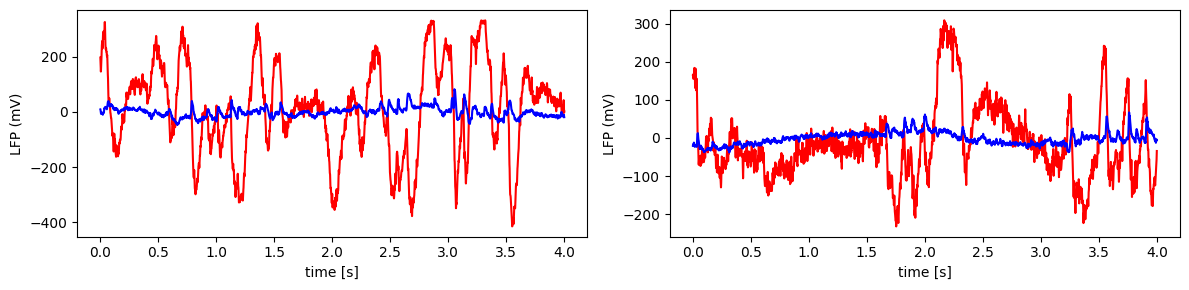

In [10]:
# plot first trial
fig, ax = plt.subplots(1,2, figsize=(12,3))

# hits
ax[0].plot(time, acc_hits[0, :], color = 'red')
ax[0].plot(time, lc_hits[0, :], color = 'blue')
ax[0].set_xlabel('time [s]')
ax[0].set_ylabel('LFP (mV)')

# false alarms
ax[1].plot(time, acc_fa[0, :], color = 'red')
ax[1].plot(time, lc_fa[0, :], color = 'blue')
ax[1].set_xlabel('time [s]')
ax[1].set_ylabel('LFP (mV)')

plt.tight_layout()

I think the dominant oscillation in the ACC LFP is about 3 Hz, and maybe 2-3 Hz for the LC LFP too. It's a bit hard to distinguish the peaks for the LC LFP since it is relatively flat compared to the ACC LFP. During the hits and false alarms, it seems like during the troughs of the ACC LFP the LC LFP peaks, to some extent.

Text(0.5, 1.0, 'Coherence between two electrodes')

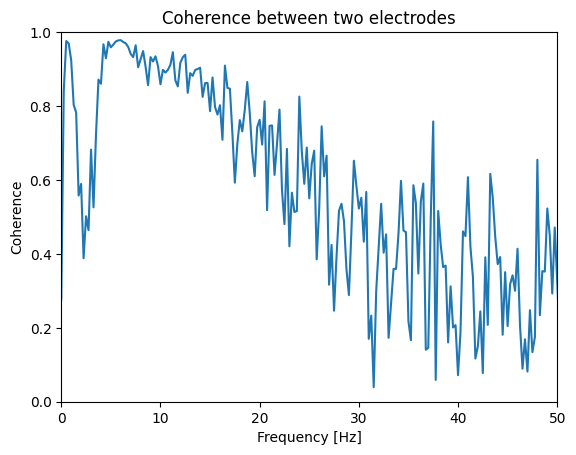

In [15]:
N = acc_hits.shape[1]
dt = time[1] - time[0]

# Compute the Fourier transforms
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_hits])  # ... for each trial in E1
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_hits])  # ... and each trial in E2

# Compute the spectra
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)  # Spectrum of E1 trials
Syy = scale * (yf * yf.conj()).mean(0)  # ... and E2 trials
Sxy = scale * (xf * yf.conj()).mean(0)  # ... and the cross spectrum

# Compute the coherence.
cohr = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

f1 = np.fft.rfftfreq(N, dt)                     # Define a frequency axis.
plt.plot(f1, cohr.real)                      # Plot coherence vs frequency,
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                            # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')

The best coherence seems to be around 2-3 Hz, which is consistent with what was observed earlier. 7-9 Hz also seems to have good coherence.

Text(0.5, 1.0, 'Coherence between two electrodes')

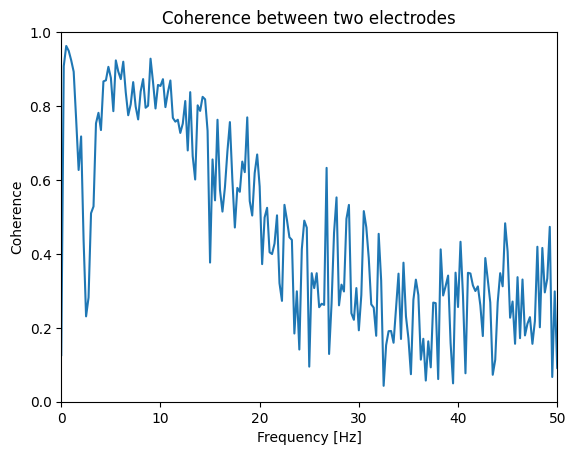

In [16]:
N = acc_hits.shape[1]
dt = time[1] - time[0]

# Compute the Fourier transforms
xf = np.array([np.fft.rfft(x - x.mean()) for x in acc_fa])  # ... for each trial in E1
yf = np.array([np.fft.rfft(y - y.mean()) for y in lc_fa])  # ... and each trial in E2

# Compute the spectra
T = time[-1]
scale = 2 * dt**2 / T
Sxx = scale * (xf * xf.conj()).mean(0)  # Spectrum of E1 trials
Syy = scale * (yf * yf.conj()).mean(0)  # ... and E2 trials
Sxy = scale * (xf * yf.conj()).mean(0)  # ... and the cross spectrum

# Compute the coherence.
cohr2 = np.abs(Sxy) / (np.sqrt(Sxx) * np.sqrt(Syy))

f = np.fft.rfftfreq(N, dt)                     # Define a frequency axis.
plt.plot(f, cohr2.real)                      # Plot coherence vs frequency,
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                            # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')

Best coherence for about 1 Hz.

Text(0.5, 1.0, 'Coherence between two electrodes')

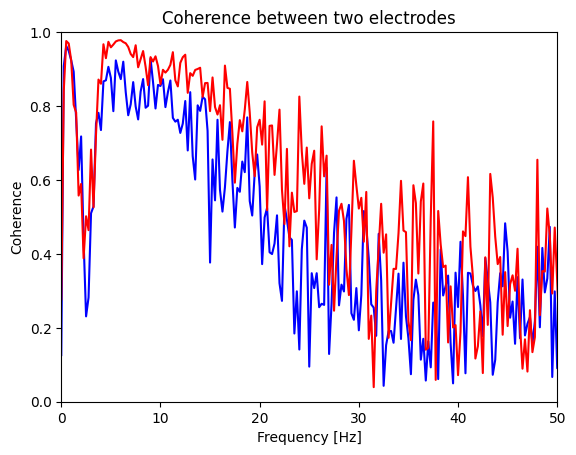

In [19]:
# plot showing results of both coherence plots

plt.plot(f, cohr2.real, color = 'blue')                      # Plot coherence vs frequency,
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                            # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence between two electrodes')

plt.plot(f1, cohr.real, color = 'red')                      # Plot coherence vs frequency,
plt.xlim([0, 50])                           # ... in a chosen frequency range,
plt.ylim([0, 1])                            # ... with y-axis scaled,
plt.xlabel('Frequency [Hz]')                # ... and with axes labeled.
plt.ylabel('Coherence')
plt.title('Coherence for ACC and LC')

Coherence is strong for both hits and false alarms at about 1-2 ish Hz. There is higher coherence for the hits than for the false alarms overall when looking at the graph. This suggests that the ACC and LC are talking to each other more during the hits compared to during the false alarms.